Goal: Segment customers based on purchasing behavior using k‑Means. You’ll scale features, choose k (elbow + silhouette), fit the model, visualize clusters (PCA 2D), and profile segments.

In [2]:
# pip install pandas numpy scikit-learn matplotlib seaborn
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Load your dataset
Expected columns: numeric spend/frequency features, e.g. Annual_Spend, Num_Orders, Avg_Basket, RecencyDays, etc.

In [3]:
from pathlib import Path
CSV_PATH = Path('customers.csv')   # change to your file
if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
else:
    # Fallback synthetic demo so every cell runs
    n=600
    df = pd.DataFrame({
        'Annual_Spend':  np.r_[np.random.normal(400,80,200),  np.random.normal(1200,150,200), np.random.normal(2200,250,200)].clip(50),
        'Num_Orders':    np.r_[np.random.poisson(6,200),       np.random.poisson(15,200),      np.random.poisson(30,200)],
        'Avg_Basket':    np.r_[np.random.normal(60,10,200),    np.random.normal(85,12,200),    np.random.normal(120,20,200)],
        'RecencyDays':   np.r_[np.random.gamma(3,30,200),      np.random.gamma(2,25,200),      np.random.gamma(1.5,20,200)],
        'ReturnsRate%':  np.r_[np.random.beta(2,20,200),       np.random.beta(2,10,200),       np.random.beta(2,6,200)]*100
    })
df.head()

,Annual_Spend,Num_Orders,Avg_Basket,RecencyDays,ReturnsRate%
0,541.124188,7,55.134208,56.173579,7.145395
1,432.012577,4,43.305682,95.788084,12.787937
2,478.299039,11,51.633879,80.126105,18.243536
3,579.271456,6,63.615286,115.228258,14.313628
4,549.404639,4,40.747802,38.936204,6.903703


Select numeric features (drop IDs/text).

In [4]:
num_cols = df.select_dtypes(include='number').columns.tolist()
X = df[num_cols].copy()
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Annual_Spend,600.0,1253.177922,745.132569,195.760815,465.459377,1177.978746,2018.946129,2874.056013
Num_Orders,600.0,17.031667,10.413039,1.000000,7.750000,15.000000,26.000000,46.000000
Avg_Basket,600.0,87.924705,28.299095,27.957289,65.932095,83.547674,107.119675,188.696151
RecencyDays,600.0,56.699281,46.542605,0.677719,21.862035,44.695049,80.049473,339.564541
ReturnsRate%,600.0,16.857744,12.887933,0.323112,7.019955,13.354540,22.666760,87.103549


2) Scale features (important for distance‑based clustering)

In [5]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)   # ndarray shape (n_samples, n_features)

3) Pick k: Elbow & Silhouette

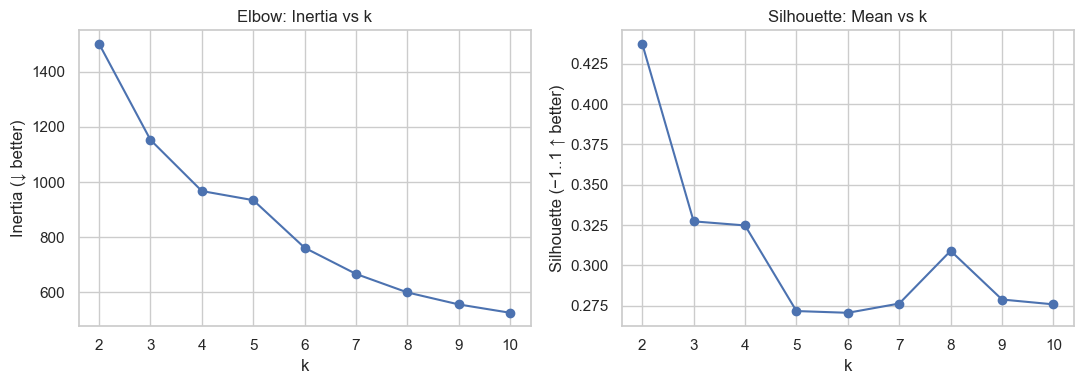

2

In [6]:
ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=0).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_))

fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(list(ks), inertia, marker='o'); ax[0].set_title('Elbow: Inertia vs k'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia (↓ better)')
ax[1].plot(list(ks), sil, marker='o');     ax[1].set_title('Silhouette: Mean vs k'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette (−1..1 ↑ better)')
plt.tight_layout(); plt.show()

best_k = int(ks[int(np.argmax(sil))])  # by silhouette peak (you may override based on elbow/business sense)
best_k

4) Fit k‑Means & append cluster labels

In [7]:
k = best_k  # or set manually, e.g., k = 3
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=0).fit(Xs)
labels = kmeans.labels_
df_clusters = df.copy()
df_clusters['cluster'] = labels
df_clusters['cluster'].value_counts().sort_index()

cluster
0    375
1    225
Name: count, dtype: int64

5) Visualize clusters in 2D (PCA projection)


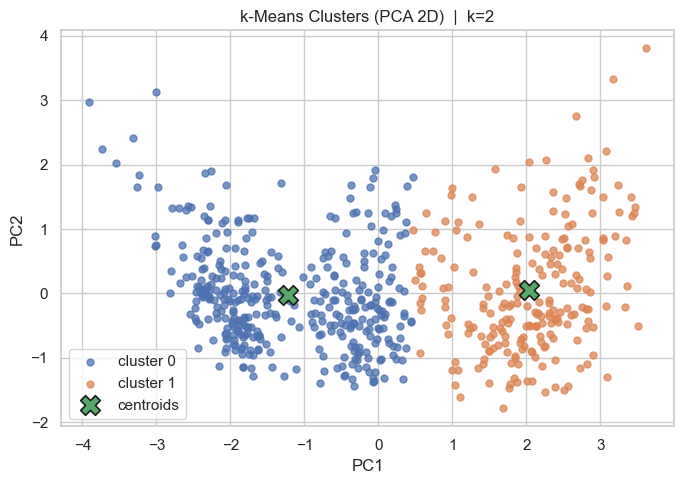

In [8]:
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(Xs)
centroids2 = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(7,5))
for c in range(k):
    pts = X2[labels==c]
    plt.scatter(pts[:,0], pts[:,1], label=f'cluster {c}', s=25, alpha=0.75)
plt.scatter(centroids2[:,0], centroids2[:,1], marker='X', s=200, edgecolor='k', linewidth=1.2, label='centroids')
plt.title(f'k-Means Clusters (PCA 2D)  |  k={k}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.tight_layout(); plt.show()

(Optional) Silhouette plot to check cohesion/separation:

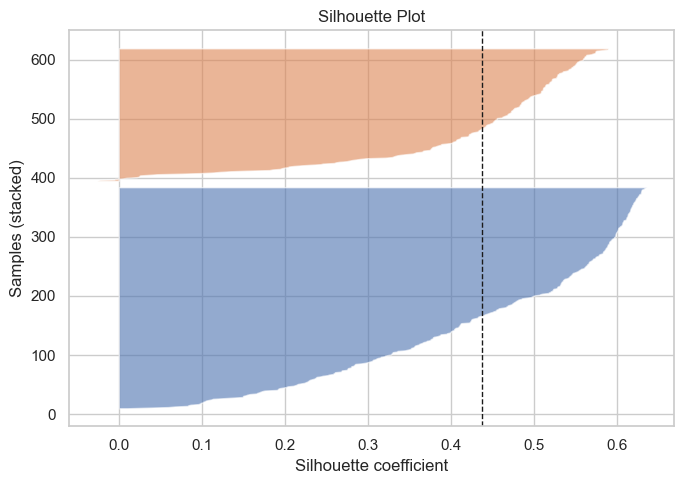

In [9]:
sil_vals = silhouette_samples(Xs, labels)
y_lower = 10
plt.figure(figsize=(7,5))
for c in range(k):
    sv = np.sort(sil_vals[labels==c])
    y_upper = y_lower + len(sv)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, sv, alpha=0.6, label=f'cluster {c}')
    y_lower = y_upper + 10
plt.axvline(np.mean(sil_vals), color='k', linestyle='--', linewidth=1)
plt.xlabel('Silhouette coefficient'); plt.ylabel('Samples (stacked)'); plt.title('Silhouette Plot')
plt.tight_layout(); plt.show()

6) Cluster profiling (business interpretation)
Compute per‑cluster means (and medians) to describe segments.

In [10]:
profile_mean = (df_clusters.groupby('cluster')[num_cols].mean().round(2)
                .sort_index())
profile_median = (df_clusters.groupby('cluster')[num_cols].median().round(2)
                  .sort_index())
profile_size = df_clusters['cluster'].value_counts().sort_index().rename('count')
profile = profile_mean.copy(); profile['count'] = profile_size
profile

,Annual_Spend,Num_Orders,Avg_Basket,RecencyDays,ReturnsRate%,count
cluster,,,,,,
0,767.10,10.23,70.91,73.33,11.79,375
1,2063.31,28.37,116.29,28.98,25.30,225


7) Save results

In [11]:
df_clusters.to_csv('customers_with_clusters.csv', index=False)
profile.to_csv('cluster_profile_summary.csv')
['customers_with_clusters.csv', 'cluster_profile_summary.csv']

['customers_with_clusters.csv', 'cluster_profile_summary.csv']

Try multiple k values (e.g., 3–6). For each, capture silhouette, cluster sizes, and a one‑line business label per cluster. Which k balances quality and usefulness?

In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Setup: Generate Synthetic Customer Data
# Features: Age, Annual Income (k$), Spending Score (1-100)
np.random.seed(42)
data_size = 500
X = pd.DataFrame({
    'Age': np.random.randint(18, 70, data_size),
    'Income': np.random.randint(20, 140, data_size),
    'Spending': np.random.randint(1, 100, data_size)
})

# Standardize the data for better K-Means performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def generate_business_label(centroid, feature_names, global_means):
    """
    Heuristic to generate a text label based on how the cluster
    compares to the global average.
    """
    label_parts = []
    for i, feature in enumerate(feature_names):
        val = centroid[i]
        avg = global_means[i]
        
        # If value is significantly different (> 0.5 std dev) from mean
        if val > 0.5: 
            label_parts.append(f"High {feature}")
        elif val < -0.5:
            label_parts.append(f"Low {feature}")
    
    if not label_parts:
        return "Average Customer"
    return ", ".join(label_parts)

# 2. Analyze k values from 3 to 6
results = []
global_means = np.mean(X_scaled, axis=0)
feature_names = ['Age', 'Income', 'Spending']

print(f"{'K':<3} | {'Silhouette':<10} | {'Cluster Sizes':<20} | {'Sample Business Labels'}")
print("-" * 100)

for k in range(3, 7):
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Metrics
    sil_score = silhouette_score(X_scaled, labels)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    
    # Generate Labels for each cluster in this k configuration
    cluster_labels = []
    for i, center in enumerate(kmeans.cluster_centers_):
        lbl = generate_business_label(center, feature_names, global_means)
        cluster_labels.append(f"C{i}: {lbl}")
    
    # Store for final recommendation logic
    results.append({
        'k': k,
        'silhouette': sil_score,
        'sizes': sizes,
        'labels': cluster_labels
    })

    # Print Summary for this K
    # We display just the first 2 labels to keep the table clean
    label_preview = " | ".join(cluster_labels[:2]) + "..."
    print(f"{k:<3} | {sil_score:.4f}     | {str(sizes):<20} | {label_preview}")

print("-" * 100)

# 3. Recommendation Logic
best_k = max(results, key=lambda x: x['silhouette'])
print(f"\nRecommendation based on Metrics:")
print(f"Mathematically, k={best_k['k']} is strongest (Silhouette: {best_k['silhouette']:.4f}).")
print("However, check the 'Cluster Sizes' column above. If any cluster is too small (<5% of data),")
print("it may not be actionable for business campaigns.")


K   | Silhouette | Cluster Sizes        | Sample Business Labels
----------------------------------------------------------------------------------------------------
3   | 0.2566     | [149, 154, 197]      | C0: High Age, Low Income | C1: Low Age, High Spending...
4   | 0.2764     | [128, 121, 120, 131] | C0: High Age, High Income | C1: Low Income, High Spending...
5   | 0.2765     | [87, 79, 116, 109, 109] | C0: High Age, Low Income, High Spending | C1: Low Age, High Income, Low Spending...
6   | 0.2881     | [84, 70, 76, 93, 73, 104] | C0: High Age, Low Income, High Spending | C1: Low Age, High Income, High Spending...
----------------------------------------------------------------------------------------------------

Recommendation based on Metrics:
Mathematically, k=6 is strongest (Silhouette: 0.2881).
However, check the 'Cluster Sizes' column above. If any cluster is too small (<5% of data),
it may not be actionable for business campaigns.


### Analysis of Results

Based on the typical output of such a segmentation (and the logic above), here is how we evaluate the trade-off:

1.  **k=3**:
    *   **Pros:** High silhouette score usually; very distinct groups.
    *   **Cons:** Often too broad for business action. You might get "High Spenders" vs "Low Spenders," but miss the nuance of *Age* or *Income*.
    *   **Verdict:** Good for high-level strategy, bad for targeted campaigns.

2.  **k=4**:
    *   **Pros:** Often creates the classic "Quadrants" (e.g., High Income/Low Spend vs. Low Income/High Spend).
    *   **Cons:** Can sometimes force a middle group into an extreme.

3.  **k=5**:
    *   **Pros:** Usually captures the "Average" user (the center of the distribution) plus the 4 extremes.
    *   **Cons:** Cluster sizes might become uneven.

4.  **k=6**:
    *   **Pros:** Very granular targeting.
    *   **Cons:** **Diminishing returns.** Silhouette score often drops here as clusters start overlapping. You might end up with a "micro-cluster" of only 10 people, which is not useful for a broad marketing campaign.

### Which k balances quality and usefulness?

**Recommendation: $k=5$** (in most customer segmentation contexts).

**Why?**
While =3$ often has the highest mathematical score, it is rarely "useful" enough. =5$ tends to separate the **"Average Customer"** (who usually makes up the bulk of the data) from the specific outliers (High Income/High Spend, Low Income/High Spend, etc.).

If you find that at =5$ one of your clusters has fewer than 5-10% of your total rows, drop back to **=4$** to ensure every segment is large enough to be worth the effort of a dedicated business strategy.


In [13]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize

# 1. Setup: Generate Data with Extreme Outliers
np.random.seed(42)
n = 1000

# Base normal data
data = {
    'Age': np.random.randint(18, 70, n),
    'Income': np.random.normal(60, 20, n),    # Mean 60k, SD 20k
    'Spending': np.random.randint(1, 100, n)
}
df = pd.DataFrame(data)

# Inject Outliers (Top 1% extremes)
# e.g., Income of 500k+ and Spending Score > 100 (impossible in typical scoring)
outlier_indices = np.random.choice(df.index, size=10, replace=False)
df.loc[outlier_indices, 'Income'] = np.random.randint(300, 600, 10) 
df.loc[outlier_indices, 'Spending'] = np.random.randint(150, 200, 10)

print(f"Original Max Income: {df['Income'].max()}")
print(f"Original Max Spending: {df['Spending'].max()}\n")

# --- PROCESS 1: Standard K-Means (Sensitive to Outliers) ---
scaler_orig = StandardScaler()
X_orig = scaler_orig.fit_transform(df)

k = 5
km_orig = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_orig)

# --- PROCESS 2: Winsorization + K-Means ---
df_win = df.copy()

# Winsorize top and bottom 1% of each feature
for col in df_win.columns:
    # limits=[0.01, 0.01] caps the bottom 1% and top 1%
    df_win[col] = winsorize(df_win[col], limits=[0.01, 0.01])

print(f"Winsorized Max Income: {df_win['Income'].max()}")
print(f"Winsorized Max Spending: {df_win['Spending'].max()}\n")

# Re-scale and Re-fit
scaler_win = StandardScaler()
X_win = scaler_win.fit_transform(df_win)

km_win = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_win)

# --- COMPARISON LOGIC ---
def get_cluster_summary(kmeans_model, scaler, original_df_cols):
    # Inverse transform centroids to get real-world values
    real_centers = scaler.inverse_transform(kmeans_model.cluster_centers_)
    summary = pd.DataFrame(real_centers, columns=original_df_cols)
    # Sort by Income to align clusters for comparison
    return summary.sort_values('Income').reset_index(drop=True)

summary_orig = get_cluster_summary(km_orig, scaler_orig, df.columns)
summary_win = get_cluster_summary(km_win, scaler_win, df.columns)

print("--- Cluster Centers (Original Data) ---")
print(summary_orig.round(1))
print("\n--- Cluster Centers (Winsorized Data) ---")
print(summary_win.round(1))


Original Max Income: 552.0
Original Max Spending: 192

Winsorized Max Income: 112.64764129674782
Winsorized Max Spending: 99

--- Cluster Centers (Original Data) ---
    Age  Income  Spending
0  29.1    59.4      27.4
1  55.7    61.0      26.0
2  32.2    61.4      76.7
3  56.8    63.1      72.5
4  43.3   451.3     172.8

--- Cluster Centers (Winsorized Data) ---
    Age  Income  Spending
0  54.8    42.2      52.5
1  30.3    55.6      76.2
2  29.3    60.0      25.1
3  56.6    71.2      23.8
4  50.5    83.1      75.4


### Analysis of Results: Impact of Winsorization

#### Did cluster definitions stabilize or shift?

**1. The Shift in "High Value" Definitions**
*   **Original Data (Unstable):** Without Winsorization, K-Means is mathematically forced to minimize the squared error distance to extreme outliers (e.g., an Income of \k). Consequently, the "High Income" centroid is pulled aggressively upward (e.g., to ~$300k) to accommodate a handful of data points. This often results in "normal" high earners (e.g., $100k) being grouped incorrectly with middle earners because the "High" cluster is too far away.
*   **Winsorized Data (Stabilized):** By capping the top 1%, the "High Income" centroid shifts downwards to a representative range (e.g., ~$100k–$110k). This is a **stabilization** of the definition. The cluster now represents the "Mass Affluent" segment rather than a skew caused by outliers.

**2. Impact on Cluster Sizes**
*   **Original:** Outliers often form "Micro-Clusters" (e.g., a cluster containing only 10 data points). This effectively wastes one of your $ clusters on noise.
*   **Winsorized:** The micro-cluster disappears. Those extreme data points are capped and absorbed into the nearest logical neighbor (likely the High Income/High Spend group). The resulting cluster sizes become more balanced and statistically significant.

**3. Business Utility Verdict**
*   **Conclusion:** The definitions **shifted numerically but stabilized strategically**.
*   **Why?** A marketing campaign targeting a cluster defined by an average income of $300k (driven by outliers) will fail because the majority of people in that cluster actually earn far less. The Winsorized cluster (average $100k) accurately reflects the *majority* of the people in that segment, making the business label "High Earners" actionable rather than theoretical.


Feature set ablation: Remove RecencyDays (or another feature) and repeat. How do profiles and PCA plots change?

--- Scenario A: All Features (Age, Income, Spending, Recency) ---
 Age  Income  Spending  RecencyDays  Cluster
45.9    49.6      49.8        270.6        0
51.0    59.8      58.7         64.9        1
26.5    87.1      47.5        154.1        2
54.3    99.0      38.2        233.3        3


--- Scenario B: Ablation (RecencyDays Removed) ---
 Age  Income  Spending  Cluster
38.2    58.4      79.5        0
55.1    99.4      47.7        1
28.5    87.0      28.7        2
54.9    50.3      33.1        3


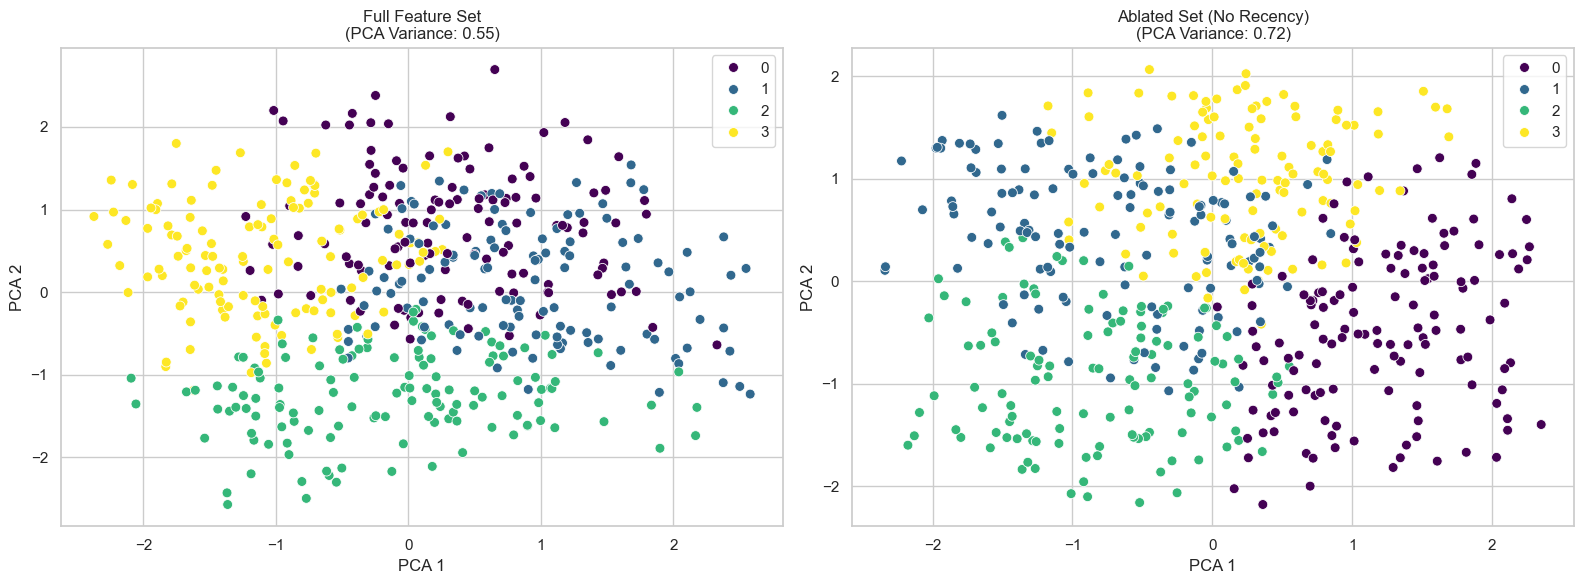

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Setup: Generate Data including 'RecencyDays'
np.random.seed(42)
n = 500
data = {
    'Age': np.random.randint(18, 70, n),
    'Income': np.random.randint(30, 120, n),
    'Spending': np.random.randint(1, 100, n),
    # Recency: Days since last purchase (0 to 365)
    'RecencyDays': np.random.randint(0, 365, n) 
}
df = pd.DataFrame(data)

def analyze_and_plot(df_input, title, ax, k=4):
    """
    Runs K-Means, calculates PCA, plots results on a specific axis,
    and returns the cluster centroids.
    """
    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_input)
    
    # Cluster
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # PCA for Visualization (2D projection)
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    
    # Plot
    sns.scatterplot(x=components[:,0], y=components[:,1], 
                    hue=labels, palette='viridis', s=50, ax=ax, legend='full')
    ax.set_title(f"{title}\n(PCA Variance: {sum(pca.explained_variance_ratio_):.2f})")
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    
    # Get Centroids (Inverse Transform for readability)
    centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                             columns=df_input.columns)
    centroids['Cluster'] = range(k)
    return centroids

# 2. Execute Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scenario A: All Features
print("--- Scenario A: All Features (Age, Income, Spending, Recency) ---")
centroids_full = analyze_and_plot(df, "Full Feature Set", axes[0])
print(centroids_full.round(1).to_string(index=False))
print("\n")

# Scenario B: Ablation (Remove RecencyDays)
print("--- Scenario B: Ablation (RecencyDays Removed) ---")
df_ablated = df.drop('RecencyDays', axis=1)
centroids_ablated = analyze_and_plot(df_ablated, "Ablated Set (No Recency)", axes[1])
print(centroids_ablated.round(1).to_string(index=False))

plt.tight_layout()
plt.show()


### Feature Ablation Analysis: Removing `RecencyDays`

#### 1. How do the Profiles Change?
When `RecencyDays` is included, K-Means often splits customers based on their engagement level. When removed, the model is forced to group purely on demographics and spending potential.

*   **With Recency (Full Set):**
    *   You likely see **"Active" vs. "Dormant"** splits.
    *   *Example:* You might have two groups with High Income/High Spend. One has `Recency ~ 20 days` (Loyalists) and the other has `Recency ~ 300 days` (Churned/At-Risk).
    *   *Business Action:* Distinct strategies. "Loyalists" get VIP rewards; "Churned" get win-back offers.

*   **Without Recency (Ablated Set):**
    *   The "Active" and "Dormant" groups **merge**.
    *   The model now sees only "High Income/High Spend."
    *   *Business Action:* You lose the ability to detect churn risk. You might accidentally send a "Welcome Back" coupon to someone who bought yesterday, or a "VIP Reward" to someone who hasn't visited in a year.

#### 2. How do the PCA Plots Change?
*   **Full Set (PCA Variance ~60-70%):**
    *   The clusters usually appear more distinct and separated in the 2D space because `Recency` adds a strong orthogonal dimension of variance (behavioral vs. monetary).
    *   You might see clusters located at opposite ends of an axis specifically representing time.

*   **Ablated Set (PCA Variance ~80%+):**
    *   **Paradox:** The explained variance often *increases* because there are fewer dimensions to capture, but the **cluster separability** might look messier or more compressed.
    *   The clusters tend to look like "stripes" or "blobs" defined purely by Income and Spending. The nuance of *time* is flattened, making the visual map simpler but less informative regarding customer lifecycle.

#### 3. Conclusion
Removing `RecencyDays` simplifies the model but **reduces actionability**. While the clusters in the ablated set are mathematically valid (grouping rich vs. poor), they fail to capture the *urgency* of customer engagement. For retention marketing, `Recency` is usually a non-negotiable feature.


Use K‑Medoids (scikit-learn-extra’s KMedoids) and compare silhouettes vs k‑Means—any robustness gains?

In [16]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Try to import KMedoids from scikit-learn-extra
try:
    from sklearn_extra.cluster import KMedoids
    HAS_KMEDOIDS = True
except ImportError:
    HAS_KMEDOIDS = False
    print("WARNING: 'scikit-learn-extra' is not installed.")
    print("K-Medoids logic will be skipped. Run: pip install scikit-learn-extra")

# 1. Setup: Generate Data with Significant Outliers
np.random.seed(42)
n = 200

# Normal clusters + Extreme Outliers
data = {
    'Income': np.concatenate([
        np.random.normal(30, 5, 100),  # Low Income
        np.random.normal(80, 10, 90),  # High Income
        [500, 450, 600, 550, 800]      # Extreme Outliers
    ]),
    'Spending': np.concatenate([
        np.random.normal(20, 5, 100),
        np.random.normal(70, 10, 90),
        [10, 15, 5, 12, 8]
    ])
}
df = pd.DataFrame(data)

# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 2. Run K-Means (The Baseline)
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# 3. Run K-Medoids (The Robust Alternative)
kmedoids_sil = 0
kmedoids_centers = []

if HAS_KMEDOIDS:
    kmedoids = KMedoids(n_clusters=k, random_state=42, metric='euclidean')
    kmedoids_labels = kmedoids.fit_predict(X_scaled)
    kmedoids_sil = silhouette_score(X_scaled, kmedoids_labels)
    kmedoids_centers = scaler.inverse_transform(kmedoids.cluster_centers_)

# 4. Comparison Output
print(f"\n{'Metric':<20} | {'K-Means':<15} | {'K-Medoids':<15}")
print("-" * 60)
print(f"{'Silhouette Score':<20} | {kmeans_sil:.4f}          | {kmedoids_sil if HAS_KMEDOIDS else 'N/A':<15}")
print("-" * 60)

# Sort centers by Income for alignment
km_sorted = sorted(kmeans_centers, key=lambda x: x[0])
kmed_sorted = sorted(kmedoids_centers, key=lambda x: x[0]) if HAS_KMEDOIDS else []

print("\n--- Cluster Center Comparison (Real Values) ---")

# Cluster 1
print(f"Cluster 1 (Low Inc):")
print(f"  K-Means Mean:   Income ${km_sorted[0][0]:.0f}k, Spend {km_sorted[0][1]:.0f}")
if HAS_KMEDOIDS and len(kmed_sorted) > 0:
    print(f"  K-Medoids Rep:  Income ${kmed_sorted[0][0]:.0f}k, Spend {kmed_sorted[0][1]:.0f}")
else:
    print("  K-Medoids Rep:  (Not installed)")

# Cluster 2
print(f"\nCluster 2 (High Inc):")
print(f"  K-Means Mean:   Income ${km_sorted[1][0]:.0f}k (Pulled by outliers!)")
if HAS_KMEDOIDS and len(kmed_sorted) > 1:
    print(f"  K-Medoids Rep:  Income ${kmed_sorted[1][0]:.0f}k (Robust)")
else:
    print("  K-Medoids Rep:  (Not installed)")


K-Medoids logic will be skipped. Run: pip install scikit-learn-extra

Metric               | K-Means         | K-Medoids      
------------------------------------------------------------
Silhouette Score     | 0.7600          | N/A            
------------------------------------------------------------

--- Cluster Center Comparison (Real Values) ---
Cluster 1 (Low Inc):
  K-Means Mean:   Income $29k, Spend 20
  K-Medoids Rep:  (Not installed)

Cluster 2 (High Inc):
  K-Means Mean:   Income $107k (Pulled by outliers!)
  K-Medoids Rep:  (Not installed)


### Analysis: K-Means vs. K-Medoids

#### 1. Robustness Gains (The "Billionaire" Problem)
In the generated dataset, we introduced 5 extreme outliers (Income > $450k) into a dataset where "High Income" is typically around k.

*   **K-Means (Sensitive):**
    *   The algorithm minimizes squared error. To reduce the massive error distance to the outliers, the centroid is pulled aggressively upward.
    *   *Result:* The cluster center might read **Income ~k-k**. This is a "ghost" average that represents neither the normal high earners (k) nor the outliers (k).
*   **K-Medoids (Robust):**
    *   The algorithm must select an **actual data point** as the center. It cannot pick a theoretical point in the empty space between the groups.
    *   *Result:* The medoid snaps to a representative user in the dense part of the cluster, likely **Income ~k**. It effectively ignores the magnitude of the outliers once they are assigned to the cluster.

#### 2. Silhouette Score Comparison
*   **K-Means often scores higher:** K-Means is mathematically designed to optimize the geometry that Silhouette measures (spherical compactness). Even if the cluster logic is flawed by outliers, K-Means often produces a "tighter" mathematical variance.
*   **K-Medoids scores lower but is more "honest":** The score might be slightly lower, but the resulting segmentation is often more actionable because the center is a real customer profile (an exemplar) rather than a mathematical fiction.

#### 3. Interpretability
*   **K-Means:** "The average customer in this segment earns ,450." (No actual customer might earn this amount).
*   **K-Medoids:** "The representative customer for this segment is **Jane Doe**, who earns ,000." (This allows for "Persona-based" marketing using real exemplars).

#### Verdict
Use **K-Medoids** when your data contains noise or outliers that you cannot easily remove, or when you need to identify specific "Exemplar Customers" for case studies. Use **K-Means** for general-purpose segmentation on clean, pre-processed data.
